<a href="https://colab.research.google.com/github/tamburins/ESAA-2022-/blob/main/DNN_1128.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/qiangwu2023/DNN_case1_interval.git

Cloning into 'DNN_case1_interval'...
remote: Enumerating objects: 433, done.
remote: Counting objects: 100% (57/57), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 433 (delta 42), reused 26 (delta 26), pack-reused 376 (from 1)
Receiving objects: 100% (433/433), 3.11 MiB | 6.50 MiB/s, done.
Resolving deltas: 100% (290/290), done.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras


# 여기부터 데이터 로드


| x-variable | SUPPORT original variable          |
| ---------- | ---------------------------------- |
| **x0**     | age                                |
| **x1**     | sex                                |
| **x2**     | number of comorbidities ? 단톡방에선 race라는디           |
| **x3**     | race  ? 이게 number of comorbidities라는디?                             |
| **x4**     | diabetes                           |
| **x5**     | dementia                           |
| **x6**     | cancer (0=no, 1=yes, 2=metastatic) |
| **x7**     | heart rate                         |
| **x8**     | mean arterial blood pressure       |
| **x9**     | respiration rate                   |
| **x10**    | temperature                        |
| **x11**    | sodium                             |
| **x12**    | white blood cell count             |
| **x13**    | creatinine                         |


In [3]:
!pip install lifelines scikit-learn pandas --quiet


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 11.0 MB/s eta 0:00:00


# Deep1

In [4]:
!git clone https://github.com/qiangwu2023/DNN_case1_interval.git
%cd DNN_case1_interval/Model_Deep1


fatal: destination path 'DNN_case1_interval' already exists and is not an empty directory.
/content/DNN_case1_interval/Model_Deep1


In [ ]:
!ls -R .


.:
Beta_estimate.py     g_additive.py	    iteration_linear.py
B_spline3.py	     g_deep.py		    Least_FD.py
C_estimation.py      g_linear.py	    Main3.py
data_generator.py    I_spline.py	    __pycache__
fig_g_3_t.jpeg	     iteration_additive.py  result_error_deep1_t.csv
fig_Lambda_3_t.jpeg  iteration_deep.py	    result_re_deep1_t.csv

./__pycache__:
Beta_estimate.cpython-310.pyc	g_linear.cpython-310.pyc
Beta_estimate.cpython-39.pyc	g_linear.cpython-39.pyc
B_spline3.cpython-310.pyc	I_spline.cpython-310.pyc
B_spline3.cpython-39.pyc	I_spline.cpython-39.pyc
C_estimation.cpython-310.pyc	iteration_additive.cpython-310.pyc
C_estimation.cpython-39.pyc	iteration_additive.cpython-39.pyc
data_generator.cpython-310.pyc	iteration_deep.cpython-310.pyc
data_generator.cpython-39.pyc	iteration_deep.cpython-39.pyc
g_additive.cpython-310.pyc	iteration_linear.cpython-310.pyc
g_additive.cpython-39.pyc	iteration_linear.cpython-39.pyc
g_deep.cpython-310.pyc		Least_FD.cpython-310.pyc
g_deep.cpython-39.pyc		Lea

In [5]:
# install package
!pip install numpy pandas matplotlib scipy torch


In [6]:
!pip install pycox torchtuples --quiet

from pycox.datasets import support
import pandas as pd

# PyCox 내부 SUPPORT dataset 로드
df = support.read_df()

df.head()

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.6/73.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.7/69.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.7/142.7 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 429.9/429.9 kB 10.9 MB/s eta 0:00:00
Dataset 'support' not locally available. Downloading...
Done


,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,duration,event
0,82.709961,1.0,2.0,1.0,0.0,0.0,0.0,160.0,55.0,16.0,38.195309,142.0,19.000000,1.099854,30.0,1
1,79.660950,1.0,0.0,1.0,0.0,0.0,1.0,54.0,67.0,16.0,38.000000,142.0,10.000000,0.899902,1527.0,0
2,23.399990,1.0,2.0,3.0,0.0,0.0,1.0,87.0,144.0,45.0,37.296879,130.0,5.199219,1.199951,96.0,1
3,53.075989,1.0,4.0,3.0,0.0,0.0,0.0,55.0,100.0,18.0,36.000000,135.0,8.699219,0.799927,892.0,0
4,71.794983,0.0,1.0,1.0,0.0,0.0,0.0,65.0,135.0,40.0,38.593750,146.0,0.099991,0.399963,7.0,1


In [7]:
############################################################
#   REAL–DATA MAIN SCRIPT for DPLCM / PLACM / Linear Cox   #
#      (Works directly with GitHub original functions)     #
############################################################

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

#from iteration_deep import Est_deep


from I_spline import I_S
from Least_FD import LFD
from sklearn.preprocessing import StandardScaler


############################################################
# 1. SEED
############################################################
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(2025)


############################################################
# 2. LOAD REAL DATA (SUPPORT)
############################################################
# ----- YOU DECIDED -----
# Option 1
Z_cols = ["x0","x1","x4","x5","x6","x13"]

# Option 2
# Z_cols = ["x0","x1","x2","x6","x13"]

all_x_cols = [c for c in df.columns if c.startswith("x")]
X_cols = [c for c in all_x_cols if c not in Z_cols]


Z = df[Z_cols].values.astype("float32")
X = df[X_cols].values.astype("float32")
scaler = StandardScaler()
X2 = X.copy()
scaler.fit(X2)

X = scaler.transform(X2).astype("float32")
T = df["duration"].values.astype("float32")
E = df["event"].values.astype("float32")


############################################################
# 3. CURRENT–STATUS TRANSFORMATION (논문 방식)
############################################################
# 논문처럼 "고정된 관찰 시점" C 선택 (모든 사람 동일)

# -----------------------------
# 3. Current status 만들기
# -----------------------------

# # 1) 중위값 방식
# C_med = np.full(len(df), df['duration'].median()).astype('float32')

# # 2) 평균값 방식
# C_mean = np.full(len(df), df['duration'].mean()).astype('float32')

# # 3) quantile-based random 방식
# q1 = df['duration'].quantile(0.4)
# q2 = df['duration'].quantile(0.6)
# C_quant = np.random.uniform(q1, q2, len(df)).astype('float32')

tau = df['duration'].max()
U = np.random.uniform(0, tau, size=len(df))
De = (df['duration'] <= U).astype(int)
C = U



In [15]:
from sklearn.model_selection import KFold
import numpy as np

K = 5  # 5-fold CV
kf = KFold(n_splits=K, shuffle=True, random_state=2025)

# Z, X, U, De는 모두 numpy array


In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# --------------------------------------------------------
# Univariate NN for additive model
# --------------------------------------------------------
class UnivariateNN(nn.Module):
    def __init__(self, n_layer=2, n_node=20):
        super().__init__()
        layers = []
        in_dim = 1
        for _ in range(n_layer):
            layers.append(nn.Linear(in_dim, n_node))
            layers.append(nn.ReLU())
            in_dim = n_node
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(-1, 1)
        return self.net(x).squeeze(-1)

# --------------------------------------------------------
# Additive model: g(x) = sum_j g_j(x_j)
# --------------------------------------------------------
class AdditiveNet(nn.Module):
    def __init__(self, p_x, n_layer=2, n_node=20):
        super().__init__()
        self.p_x = p_x
        self.f_list = nn.ModuleList(
            [UnivariateNN(n_layer, n_node) for _ in range(p_x)]
        )

    def forward(self, X):
        outs = [self.f_list[j](X[:, j]) for j in range(self.p_x)]
        return torch.stack(outs, dim=0).sum(dim=0)


## Est_deep

In [25]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim


# --------------------------------------------------------
# Torch version of I-spline (baseline cumulative hazard)
# --------------------------------------------------------
def I_spline_torch(m, c0, U, nodevec):
    """
    I-spline basis in torch.
    c0 : (m,) learnable parameters
    U : (n,) tensor
    nodevec : numpy array of knots (m+2)
    """
    # nodevec to torch
    kv = torch.tensor(nodevec, dtype=torch.float32, device=U.device)

    # (n, m) basis matrix
    n = U.shape[0]
    basis = torch.zeros((n, m), dtype=torch.float32, device=U.device)

    for j in range(m):
        left = kv[j]
        right = kv[j+2]   # cubic I-spline for m knots
        width = right - left
        width = torch.clamp(width, min=1e-6)

        # linear I-spline construction
        b = (U - left) / width
        b = torch.clamp(b, min=0.0, max=1.0)
        basis[:, j] = b

    # Λ(U) = sum_j c0_j * I_j(U)
    return basis @ c0


# --------------------------------------------------------
# Deep Partially Linear Cox Model (DPLCM) with learnable c0
# --------------------------------------------------------
def Est_deep(train_data, X_test,
             n_layer, n_node,
             n_lr, n_epoch,
             nodevec, m):

    # 1) numpy to torch
    Z = torch.tensor(train_data['Z'], dtype=torch.float32)
    X = torch.tensor(train_data['X'], dtype=torch.float32)
    U = torch.tensor(train_data['U'], dtype=torch.float32)
    De = torch.tensor(train_data['De'], dtype=torch.float32)

    Xtest = torch.tensor(X_test, dtype=torch.float32)

    n, p_z = Z.shape
    _, p_x = X.shape

    # ----------------------------------------------------
    # 2) Network g(X)
    # ----------------------------------------------------
    class NetG(nn.Module):
        def __init__(self, p, n_layer, n_node):
            super().__init__()
            layers = []
            d = p
            for _ in range(n_layer):
                layers.append(nn.Linear(d, n_node))
                layers.append(nn.ReLU())
                d = n_node
            layers.append(nn.Linear(d, 1))
            self.net = nn.Sequential(*layers)

        def forward(self, x):
            return self.net(x).squeeze(-1)

    net_g = NetG(p_x, n_layer, n_node)

    # ----------------------------------------------------
    # 3) Learnable parameters: β_z and c0
    # ----------------------------------------------------
  # 3) Learnable parameters: β_z and c0
    beta_param = torch.zeros(p_z, requires_grad=True)
    # 🔴 기존: torch.zeros(m, requires_grad=True)
    c0_param = torch.full((m,), 0.1, requires_grad=True)  # 작은 양수로 초기화

    params = list(net_g.parameters()) + [beta_param, c0_param]
    optimizer = optim.Adam(params, lr=n_lr, weight_decay=1e-4)
    eps = 1e-7

    for epoch in range(n_epoch):
        optimizer.zero_grad()

        g_train = net_g(X)
        eta = (Z * beta_param).sum(dim=1) + g_train
        eta = torch.clamp(eta, -6.0, 6.0)

        Lambda_U = I_spline_torch(m, c0_param, U, nodevec)
        # 🔴 하한 clamp 제거 또는 아주 작게만
        # Lambda_U = torch.clamp(Lambda_U, min=1e-6)

        h = Lambda_U * torch.exp(eta)
        h = torch.clamp(h, max=50.0)

        p = 1.0 - torch.exp(-h)
        p = torch.clamp(p, eps, 1 - eps)

        loglik = De * torch.log(p) + (1-De) * torch.log(1-p)
        loss = -torch.mean(loglik)

        loss.backward()
        optimizer.step()

        if epoch % 50 == 0:
            print(f"[Epoch {epoch}] loss={loss.item():.4f}, "
                  f"c0_mean={c0_param.mean().item():.4f}")

    # ----------------------------------------------------
    # 5) Output
    # ----------------------------------------------------
    with torch.no_grad():
        g_train_hat = net_g(X).cpu().numpy()
        g_test_hat = net_g(Xtest).cpu().numpy()
        beta_hat = beta_param.cpu().numpy()
        c0_hat = c0_param.cpu().numpy()

    return {
        "g_train": g_train_hat,
        "g_test": g_test_hat,
        "Beta": beta_hat,
        "c": c0_hat
    }


# Est_linear

In [26]:
# --------------------------------------------------------
# Linear Cox Model
# --------------------------------------------------------
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim


# --------------------------------------------------------
# Torch I-spline (linear version)
# --------------------------------------------------------
def I_spline_torch(m, c0, U, nodevec):
    kv = torch.tensor(nodevec, dtype=torch.float32, device=U.device)
    n = U.shape[0]
    basis = torch.zeros((n, m), dtype=torch.float32, device=U.device)

    for j in range(m):
        left = kv[j]
        right = kv[j+2]
        width = torch.clamp(right - left, min=1e-6)

        b = (U - left) / width
        b = torch.clamp(b, 0.0, 1.0)
        basis[:, j] = b

    return basis @ c0   # (n,)



# --------------------------------------------------------
# SAFE exp (overflow 방지)
# --------------------------------------------------------
def safe_exp(x):
    return torch.exp(torch.clamp(x, -20, 20))



# --------------------------------------------------------
# LINEAR COX (CURRENT-STATUS) WITH LEARNABLE BASELINE
# --------------------------------------------------------
def Est_linear(
    train_data, X_test, nodevec, m,
    n_epoch=300, lr=1e-3, verbose=True
):

    # 1) numpy → torch
    Z = torch.tensor(train_data['Z'], dtype=torch.float32)
    X = torch.tensor(train_data['X'], dtype=torch.float32)
    U = torch.tensor(train_data['U'], dtype=torch.float32)
    De = torch.tensor(train_data['De'], dtype=torch.float32)

    Xtest = torch.tensor(X_test, dtype=torch.float32)

    n, p_z = Z.shape
    _, p_x = X.shape

    # --------------------------------------------------------
    # 2) Learnable parameters (Linear Cox)
    # --------------------------------------------------------
    # --------------------------------------------------------
    # 2) Learnable parameters (Linear Cox)
    # --------------------------------------------------------
    beta_z    = torch.nn.Parameter(torch.zeros(p_z))
    beta_x    = torch.nn.Parameter(torch.zeros(p_x))
    intercept = torch.nn.Parameter(torch.zeros(1))

    # baseline hazard coefficients (raw)
    raw_c0    = torch.nn.Parameter(torch.randn(m) * 0.1)

    params = [beta_z, beta_x, intercept, raw_c0]
    optimizer = optim.Adam(params, lr=lr, weight_decay=1e-6)

    eps = 1e-7

    # --------------------------------------------------------
    # 3) TRAINING LOOP
    # --------------------------------------------------------
    for epoch in range(n_epoch):

        optimizer.zero_grad()

        # ---- positive constraint ----
        c0_param = torch.nn.functional.softplus(raw_c0) + 1e-4

        # ---- Linear predictor ----
        eta = (
            (Z * beta_z).sum(dim=1) +
            (X * beta_x).sum(dim=1) +
            intercept
        )
        eta = torch.clamp(eta, -6, 6)

        # ---- Baseline cumulative hazard ----
        Lambda_raw = I_spline_torch(m, c0_param, U, nodevec)
        Lambda_U = torch.nn.functional.softplus(Lambda_raw) + 1e-6

        # ---- hazard h = Λ(U)*exp(η) ----
        h = Lambda_U * safe_exp(eta)
        h = torch.clamp(h, 0, 50.0)

        # ---- Current-status probability p = 1-exp(-h) ----
        p = -torch.expm1(-h)
        p = torch.clamp(p, eps, 1 - eps)

        # ---- log-likelihood ----
        loglik = De * torch.log(p) + (1 - De) * torch.log1p(-p)
        loss = -loglik.mean()

        # ---- NaN 방지 ----
        if torch.isnan(loss):
            print("NaN detected → skipping iteration")
            continue

        loss.backward()

        # ---- gradient clipping ----
        torch.nn.utils.clip_grad_norm_(
            [beta_z, beta_x, intercept, raw_c0], 3.0
        )

        optimizer.step()

        if verbose and epoch % 50 == 0:
            print(f"[Epoch {epoch}] loss={loss.item():.4f}, "
                  f"c0_mean={c0_param.mean().item():.4f}, "
                  f"beta_norm={beta_z.norm().item():.4f}")

    # --------------------------------------------------------
    # 4) OUTPUT
    # --------------------------------------------------------
    with torch.no_grad():
        eta_train = (Z * beta_z).sum(dim=1) + (X * beta_x).sum(dim=1) + intercept
        eta_test  = (Xtest * beta_x).sum(dim=1) + intercept

    beta_full = np.concatenate([
    beta_z.detach().cpu().numpy(),
    beta_x.detach().cpu().numpy(),
    intercept.detach().cpu().numpy()
])
    return {
        "g_train": eta_train.cpu().numpy(),
        "g_test": eta_test.cpu().numpy(),
        "Beta": beta_full,
        "c": c0_param.detach().cpu().numpy()
    }


# Est_additive

In [23]:
def Est_additive(
        train_data,
        X_test,
        nodevec,
        m,
        n_layer=2,
        n_node=20,
        n_epoch=300,
        lr=3e-4,
        l2_penalty=1e-3,
        verbose=True
    ):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    Z = torch.tensor(train_data["Z"], dtype=torch.float32, device=device)
    X = torch.tensor(train_data["X"], dtype=torch.float32, device=device)
    U = torch.tensor(train_data["U"], dtype=torch.float32, device=device)
    De = torch.tensor(train_data["De"], dtype=torch.float32, device=device)
    Xtest = torch.tensor(X_test, dtype=torch.float32, device=device)

    n, p_z = Z.shape
    _, p_x = X.shape

    # ← 여기에서 AdditiveNet 인식됨 (NameError 해결)
    net_g = AdditiveNet(p_x, n_layer=n_layer, n_node=n_node).to(device)

    beta_z = nn.Parameter(torch.zeros(p_z, dtype=torch.float32, device=device))
    intercept = nn.Parameter(torch.zeros(1, dtype=torch.float32, device=device))
    raw_c0 = nn.Parameter(torch.randn(m, dtype=torch.float32, device=device) * 0.1)

    optimizer = optim.Adam(
        list(net_g.parameters()) + [beta_z, intercept, raw_c0],
        lr=lr, weight_decay=1e-6
    )

    eps = 1e-7
    def safe_exp(x):
        return torch.exp(torch.clamp(x, -20, 20))

    for epoch in range(n_epoch):

        optimizer.zero_grad()

        c0_param = torch.nn.functional.softplus(raw_c0) + 1e-4

        Lambda_raw = I_spline_torch(m, c0_param, U, nodevec)
        Lambda_U = torch.nn.functional.softplus(Lambda_raw) + 1e-6

        g_train = net_g(X)

        eta = (Z * beta_z).sum(dim=1) + g_train + intercept
        eta = torch.clamp(eta, -6, 6)

        h = Lambda_U * safe_exp(eta)
        h = torch.clamp(h, 0, 30)

        p = -torch.expm1(-h)
        p = torch.clamp(p, eps, 1-eps)

        loglik = De * torch.log(p) + (1-De) * torch.log1p(-p)
        nll = -loglik.mean()

        l2 = beta_z.pow(2).sum() + c0_param.pow(2).sum()
        for pp in net_g.parameters():
            l2 += pp.pow(2).sum()

        loss = nll + l2_penalty * l2

        if torch.isnan(loss):
            print(f"[Additive] Epoch {epoch} | NaN → skipped")
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(net_g.parameters(), 3.0)
        torch.nn.utils.clip_grad_norm_([beta_z, intercept, raw_c0], 3.0)

        optimizer.step()

        if verbose and epoch % 50 == 0:
            print(f"[Additive] Epoch {epoch} | loss={loss.item():.4f} | c0_mean={c0_param.mean().item():.4f}")

    with torch.no_grad():
        c0_final = torch.nn.functional.softplus(raw_c0) + 1e-4

        return {
            "g_train": net_g(X).cpu().numpy(),
            "g_test": net_g(Xtest).cpu().numpy(),
            "Beta": np.concatenate([beta_z.detach().cpu().numpy(),
                                    intercept.detach().cpu().numpy()]),
            "c": c0_final.detach().cpu().numpy()
        }


In [10]:
import torch.optim as optim

# tau = float(np.max(U_tr))
m = 10
nodevec = np.linspace(0, tau, m+2).astype("float32")
c0 = torch.zeros(m, requires_grad=True)
# # c0 dimension
# dummy_u = np.array([np.median(U_tr)], dtype="float32")
# I_tmp = I_S(m, np.ones(1), dummy_u, nodevec)
# L = I_tmp.shape[0]
# c0 = np.full(L, 0.1, dtype="float32")


In [27]:
Z = Z.values.astype("float32")  if isinstance(Z, pd.DataFrame) else Z
X = X.values.astype("float32")  if isinstance(X, pd.DataFrame) else X
U = U.values.astype("float32")  if isinstance(U, pd.Series) else U
De = De.values.astype("float32") if isinstance(De, pd.Series) else De


results = []

for fold, (tr_idx, te_idx) in enumerate(kf.split(Z)):
    print(f"Fold {fold} → train:{len(tr_idx)}, test:{len(te_idx)}")

    # train/test split
    Z_tr, Z_te = Z[tr_idx], Z[te_idx]
    X_tr, X_te = X[tr_idx], X[te_idx]
    U_tr, U_te = U[tr_idx], U[te_idx]
    De_tr, De_te = De[tr_idx], De[te_idx]

    train_data_fold = {
        "Z": Z_tr,
        "X": X_tr,
        "U": U_tr,
        "De": De_tr
    }
    test_data_fold = {
        "Z": Z_te,
        "X": X_te,
        "U": U_te,
        "De": De_te
    }
    # --- 여기서 DPLCM / Linear / Additive 다 적합 ---
    Est_de = Est_deep(
        train_data=train_data_fold,
        X_test=test_data_fold["X"],
        n_layer=3, n_node=50,
        n_lr=3e-4, n_epoch=300,
        nodevec=nodevec, m=m
    )
    Est_L = Est_linear(
        train_data=train_data_fold,
        X_test=test_data_fold["X"],
        nodevec=nodevec, m=m,
        n_epoch=300, lr=1e-3, verbose=False
    )
    Est_A = Est_additive(
        train_data=train_data_fold,
        X_test=test_data_fold["X"],
        nodevec=nodevec, m=m,
        n_layer=2, n_node=20,
        n_epoch=300, lr=3e-4,
        l2_penalty=1e-3, verbose=False
    )

    results.append({
        "Z_test": Z_te,
        "X_test": X_te,
        "U_test": U_te,
        "De_test": De_te,
        # DPLCM
        "g_te_de": Est_de["g_test"],
        "beta_de": Est_de["Beta"],
        "c_de": Est_de["c"],
        # Linear
        "g_te_L": Est_L["g_test"],
        "beta_L": Est_L["Beta"],
        "c_L": Est_L["c"],
        # Additive
        "g_te_A": Est_A["g_test"],
        "beta_A": Est_A["Beta"],
        "c_A": Est_A["c"],
    })


Fold 0 → train:7098, test:1775
[Epoch 0] loss=0.9241, c0_mean=0.1003
[Epoch 50] loss=0.4768, c0_mean=0.1114
[Epoch 100] loss=0.4696, c0_mean=0.1101
[Epoch 150] loss=0.4634, c0_mean=0.1079
[Epoch 200] loss=0.4572, c0_mean=0.1055
[Epoch 250] loss=0.4508, c0_mean=0.1029
Fold 1 → train:7098, test:1775
[Epoch 0] loss=0.8904, c0_mean=0.1003
[Epoch 50] loss=0.4842, c0_mean=0.1113
[Epoch 100] loss=0.4775, c0_mean=0.1096
[Epoch 150] loss=0.4715, c0_mean=0.1070
[Epoch 200] loss=0.4661, c0_mean=0.1042
[Epoch 250] loss=0.4606, c0_mean=0.1014
Fold 2 → train:7098, test:1775
[Epoch 0] loss=0.8560, c0_mean=0.1003
[Epoch 50] loss=0.4744, c0_mean=0.1112
[Epoch 100] loss=0.4671, c0_mean=0.1098
[Epoch 150] loss=0.4607, c0_mean=0.1077
[Epoch 200] loss=0.4541, c0_mean=0.1053
[Epoch 250] loss=0.4471, c0_mean=0.1030
Fold 3 → train:7099, test:1774
[Epoch 0] loss=0.8824, c0_mean=0.1003
[Epoch 50] loss=0.4819, c0_mean=0.1116
[Epoch 100] loss=0.4724, c0_mean=0.1106
[Epoch 150] loss=0.4661, c0_mean=0.1083
[Epoch 2

# delta - duration quantile 시각화

In [47]:
def pick_noevent_representatives(U_test, De_test, q=[0.25, 0.5, 0.75]):
    """
    Δ=0 subset에서 duration(U)의 분위수에 가장 가까운 환자 3명을 선택.
    """
    idx0 = np.where(De_test == 0)[0]
    U0 = U_test[idx0]

    reps = []
    for qi in q:
        target = np.quantile(U0, qi)
        diff = np.abs(U0 - target)
        chosen = idx0[np.argmin(diff)]
        reps.append(chosen)

    return reps


In [48]:
k = 0
res = results[k]

rep_noevent = pick_noevent_representatives(
    res["U_test"], res["De_test"],
    q=[0.25, 0.5, 0.75]
)

print(rep_noevent)
# 예: [1464, 831, 1107]


[np.int64(1464), np.int64(831), np.int64(1107)]


각 모델별 S(t) 계산함수

In [49]:
def predict_survival_for_one(i, model, results_k, t_grid, nodevec):
    Z_i = results_k["Z_test"][i]
    X_i = results_k["X_test"][i]

    if model == "de":
        g = results_k["g_te_de"][i]
        beta = results_k["beta_de"]
        c0  = results_k["c_de"]
        eta_i = Z_i @ beta + g

    elif model == "L":
        beta_full = results_k["beta_L"]
        p_z = results_k["Z_test"].shape[1]
        p_x = results_k["X_test"].shape[1]

        beta_z = beta_full[:p_z]
        beta_x = beta_full[p_z:p_z+p_x]
        intercept = beta_full[-1]
        eta_i = Z_i @ beta_z + X_i @ beta_x + intercept
        c0 = results_k["c_L"]

    else:  # Additive
        g = results_k["g_te_A"][i]
        beta = results_k["beta_A"]
        p_z = results_k["Z_test"].shape[1]
        beta_z = beta[:p_z]
        intercept = beta[-1]
        eta_i = Z_i @ beta_z + g + intercept
        c0 = results_k["c_A"]

    Lambda_t = Lambda_hat(t_grid, c0, nodevec)
    S_t = survival_curve(Lambda_t, eta_i)
    return S_t


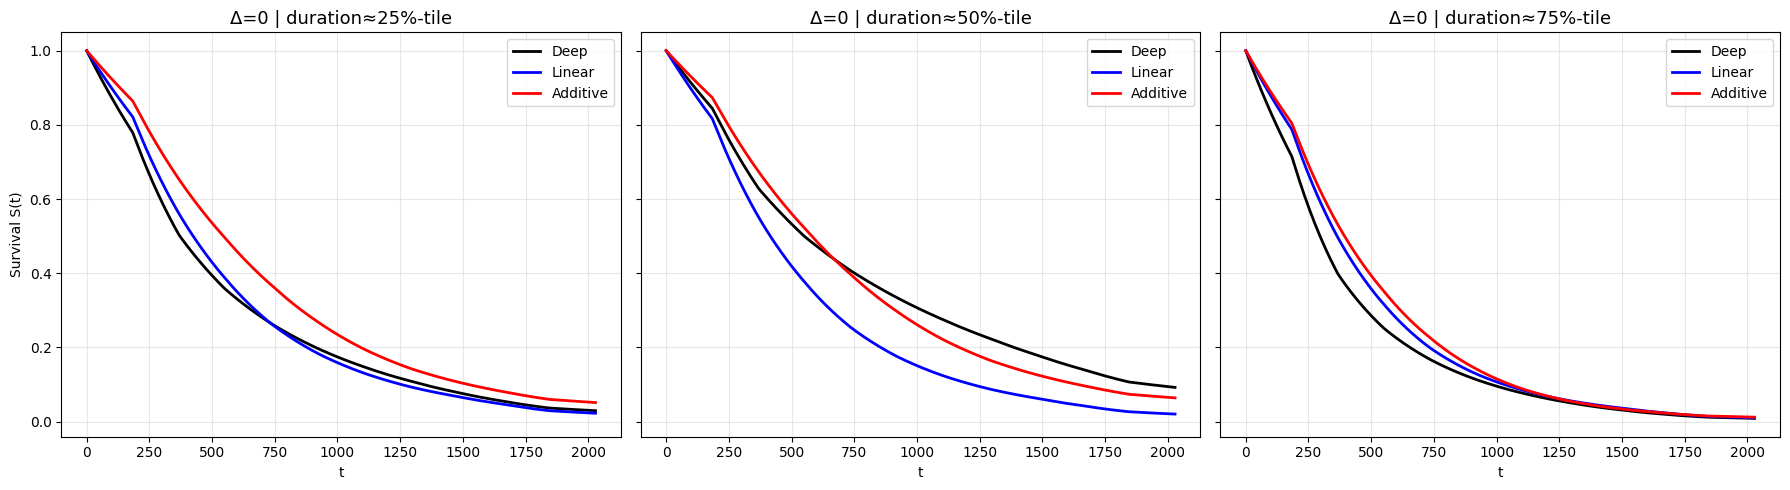

In [50]:
import matplotlib.pyplot as plt

t_grid = np.linspace(0, tau, 200)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

models = ["de", "L", "A"]
titles = ["Deep", "Linear", "Additive"]
colors = ["black", "blue", "red"]

for j, idx_i in enumerate(rep_noevent):
    ax = axes[j]

    for model, col, title in zip(models, colors, titles):
        S_t = predict_survival_for_one(idx_i, model, res, t_grid, nodevec)
        ax.plot(t_grid, S_t, color=col, label=title, linewidth=2)

    ax.set_title(f"Δ=0 | duration≈{[0.25,0.5,0.75][j]*100:.0f}%-tile", fontsize=13)
    ax.set_xlabel("t")
    if j == 0:
        ax.set_ylabel("Survival S(t)")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()


for delta = 1

In [51]:
def pick_event_representatives(U_test, De_test, q=[0.25, 0.5, 0.75]):
    """
    Δ=1 subset에서 duration(U)의 분위수에 가장 가까운 환자 3명을 선택.
    """
    idx1 = np.where(De_test == 1)[0]
    U1 = U_test[idx1]

    reps = []
    for qi in q:
        target = np.quantile(U1, qi)
        diff = np.abs(U1 - target)
        chosen = idx1[np.argmin(diff)]
        reps.append(chosen)

    return reps


In [52]:
k = 0
res = results[k]

rep_event = pick_event_representatives(
    res["U_test"], res["De_test"],
    q=[0.25, 0.5, 0.75]
)

print(rep_event)   # 예: [670, 1202, 289]


[np.int64(670), np.int64(1202), np.int64(289)]


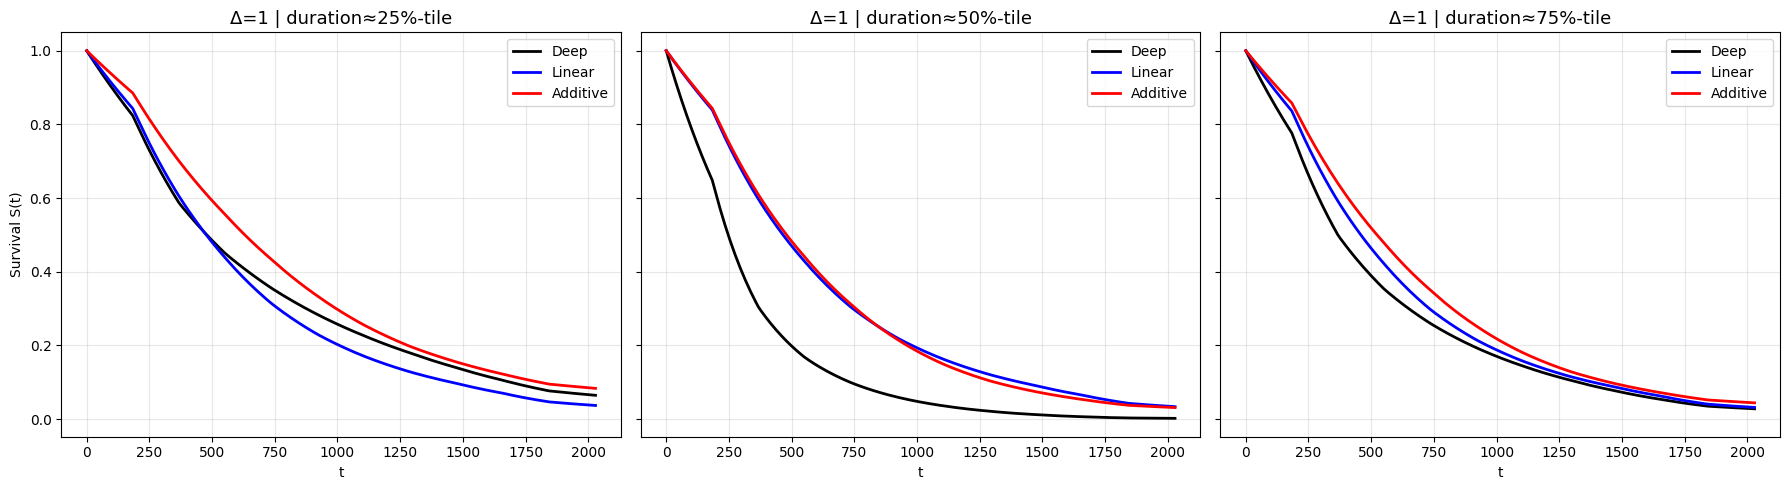

In [53]:
t_grid = np.linspace(0, tau, 200)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

models = ["de", "L", "A"]
titles = ["Deep", "Linear", "Additive"]
colors = ["black", "blue", "red"]

# Δ=1 대표 세 환자 index
q_vals = [0.25, 0.5, 0.75]
for j, idx_i in enumerate(rep_event):
    ax = axes[j]

    for model, col, title in zip(models, colors, titles):
        S_t = predict_survival_for_one(idx_i, model, res, t_grid, nodevec)
        ax.plot(t_grid, S_t, color=col, label=title, linewidth=2)

    ax.set_title(f"Δ=1 | duration≈{q_vals[j]*100:.0f}%-tile", fontsize=13)
    ax.set_xlabel("t")
    if j == 0:
        ax.set_ylabel("Survival S(t)")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()


# cumulative **hazard**

results에서 c_de, c_L, c_A 다 뽑아써야함

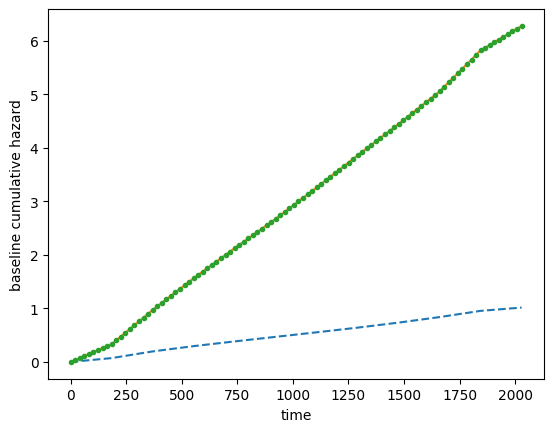

In [46]:
t_grid1 = np.linspace(0, tau, 100).astype("float32")
t_grid2 = np.linspace(0, tau, 100).astype("float32")
t_grid3 = np.linspace(0, tau, 100).astype("float32")

# --- torch-based baseline cumulative hazard ---
def I_spline_torch_single_time(m, c0_np, t, nodevec):
    c0 = torch.tensor(c0_np, dtype=torch.float32)
    t_tensor = torch.tensor([t], dtype=torch.float32)
    return I_spline_torch(m, c0, t_tensor, nodevec)[0].item()

Lambda_list1 = []
for t in t_grid1:
    Lambda_list1.append(
        I_spline_torch_single_time(
            m,          # torch model's m
            c_de,       # learned coefficients
            t,
            nodevec     # torch version nodevec
        )
    )

Lambda_list2 = []
for t in t_grid2:
    Lambda_list2.append(
        I_spline_torch_single_time(
            m,          # torch model's m
            c_L,       # learned coefficients
            t,
            nodevec     # torch version nodevec
        )
    )

Lambda_list3 = []
for t in t_grid3:
    Lambda_list3.append(
        I_spline_torch_single_time(
            m,          # torch model's m
            c_A,       # learned coefficients
            t,
            nodevec     # torch version nodevec
        )
    )

Lambda_de = np.array(Lambda_list1)
Lambda_L = np.array(Lambda_list2)
Lambda_A = np.array(Lambda_list3)

plt.plot(t_grid1, Lambda_de, '--')
plt.plot(t_grid2, Lambda_L, '-')
plt.plot(t_grid3, Lambda_L, '.')

plt.xlabel("time")
plt.ylabel("baseline cumulative hazard")
plt.show()


# Beta 그래프

# beta 시각화

In [71]:
# ----------------------------
# 1. fold별 beta 수집
# ----------------------------
beta_de_all = []
beta_L_all  = []
beta_A_all  = []

for fold in range(len(results)):
    beta_de_all.append(results[fold]["beta_de"])
    beta_L_all.append(results[fold]["beta_L"])
    beta_A_all.append(results[fold]["beta_A"])

beta_de_all = np.array(beta_de_all, dtype=object)
beta_L_all  = np.array(beta_L_all, dtype=object)
beta_A_all  = np.array(beta_A_all, dtype=object)


In [74]:
import numpy as np
import matplotlib.pyplot as plt

def plot_beta_ci_folds_offset(beta_de_Z, beta_L_Z, beta_A_Z, var_names):
    """
    beta_*_Z : shape (K, p_z)
    var_names : list of variable names in Z (length p_z)
    """

    K, p_z = beta_de_Z.shape
    folds = np.arange(1, K + 1)

    # 모델 사양 + offset
    model_specs = {
        "Deep":     {"beta": beta_de_Z, "color": "blue",  "marker": "s", "offset": -0.15},
        "Linear":   {"beta": beta_L_Z,  "color": "orange","marker": "o", "offset":  0.00},
        "Additive": {"beta": beta_A_Z,  "color": "green", "marker": "^", "offset": +0.15},
    }

    for j in range(p_z):  # 각 beta_j 에 대해 그림 하나 생성
        plt.figure(figsize=(8, 5))

        for model_name, spec in model_specs.items():
            beta_j = spec["beta"][:, j]   # shape (K,)
            color  = spec["color"]
            marker = spec["marker"]
            offset = spec["offset"]

            # offset 적용된 x좌표
            x_pos = folds + offset

            # point
            plt.scatter(x_pos, beta_j, color=color, marker=marker, s=60, label=model_name)

            # fold 간 sd 기반 CI width
            beta_sd = np.std(beta_j, ddof=1)
            ci_low  = beta_j - 1.96 * beta_sd
            ci_high = beta_j + 1.96 * beta_sd

            # error bars (model별 offset 적용)
            for f in range(K):
                plt.plot([x_pos[f], x_pos[f]], [ci_low[f], ci_high[f]],
                         color=color, linewidth=2)

        plt.title(f"β for {var_names[j]} across folds", fontsize=14)
        plt.xlabel("Fold")
        plt.ylabel("Estimate")

        plt.xticks(folds)  # 폴드 번호는 중심에 그대로
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()


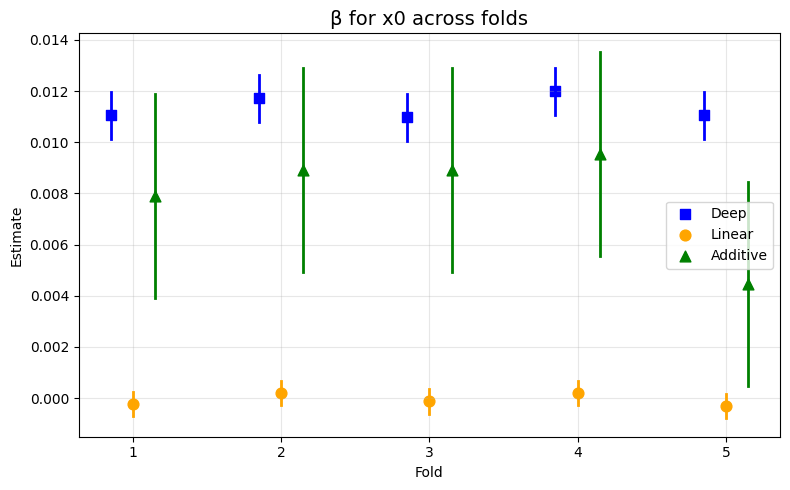

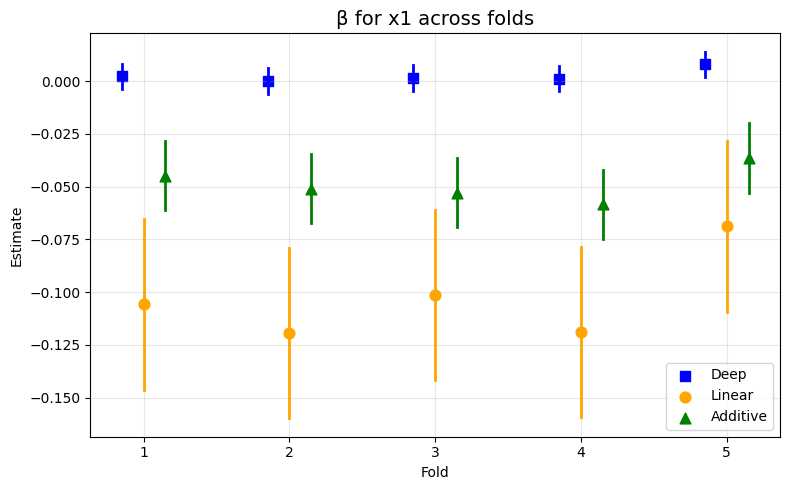

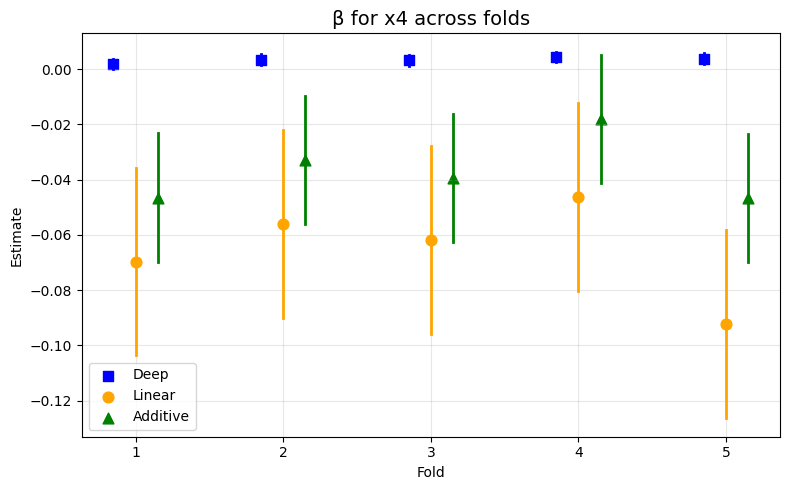

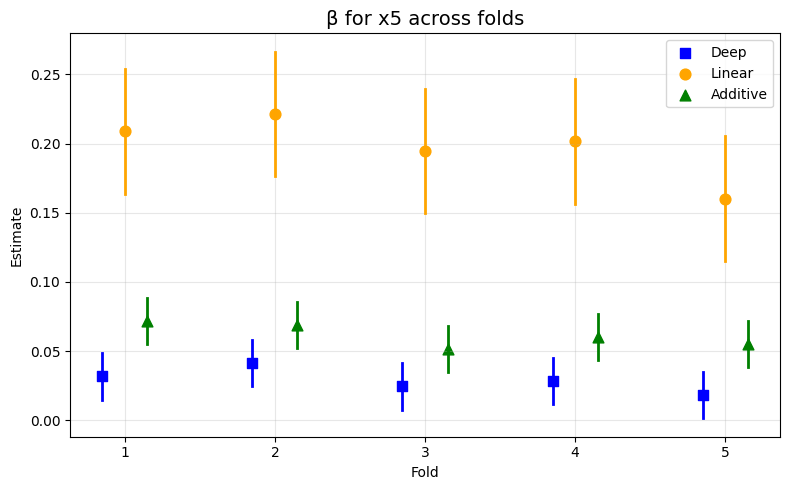

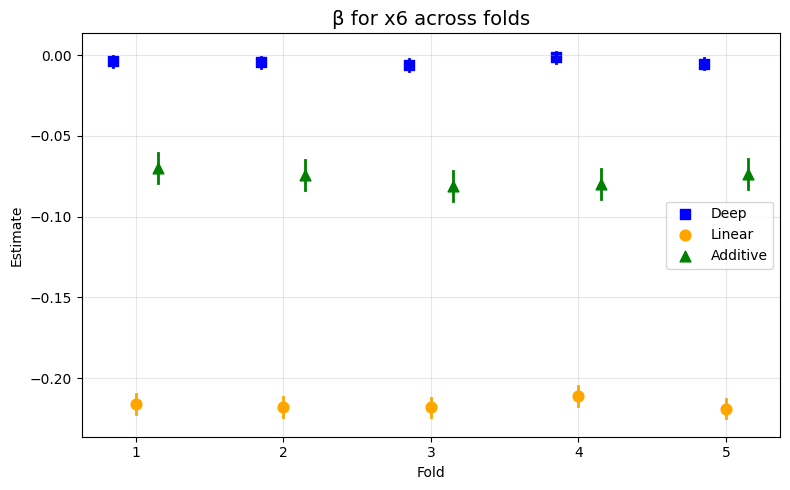

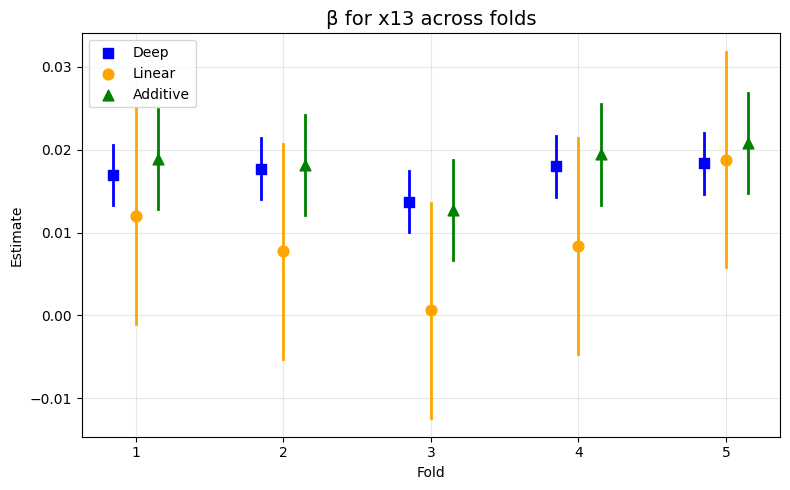

In [75]:
p_z = len(Z_cols)

beta_de_Z = np.vstack([b[:p_z] for b in beta_de_all])
beta_L_Z  = np.vstack([b[:p_z] for b in beta_L_all])
beta_A_Z  = np.vstack([b[:p_z] for b in beta_A_all])

plot_beta_ci_folds_offset(beta_de_Z, beta_L_Z, beta_A_Z, Z_cols)
